In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df=pd.read_excel(r"D:\data science 2025\git_repository\data-science-project-\project 2\Salary_Data.csv.xlsx")


In [4]:
df.head()

,Education Level,Years of Experience,Salary,skill_level
0,Bachelor's,5.0,90000.0,beginner
1,Master's,3.0,65000.0,beginner
2,PhD,15.0,150000.0,intermediate
3,Bachelor's,7.0,60000.0,intermediate
4,Master's,20.0,200000.0,expert


In [5]:
df.dtypes

Education Level            str
Years of Experience    float64
Salary                 float64
skill_level                str
dtype: object

In [6]:
#arranging degree column
df['Education Level']=df['Education Level'].str.lower()
df['Education Level']=df['Education Level'].replace({"bachelor's degree":"bachelor's","master's degree":"master's"})

# null values

In [7]:
#null values
df.isnull().sum()

Education Level        0
Years of Experience    1
Salary                 3
skill_level            0
dtype: int64

In [8]:
df.dropna(inplace=True)
df.isnull().sum()

Education Level        0
Years of Experience    0
Salary                 0
skill_level            0
dtype: int64

# duplicate rows

In [9]:
#duplicate values
df.duplicated
df[df.duplicated()]


,Education Level,Years of Experience,Salary,skill_level
32,master's,3.0,75000.0,beginner
36,bachelor's,7.0,60000.0,intermediate
38,bachelor's,1.0,40000.0,beginner
40,master's,5.0,80000.0,beginner
45,bachelor's,2.0,40000.0,beginner
...,...,...,...,...
6696,phd,20.0,200000.0,expert
6697,high school,3.0,50000.0,beginner
6698,bachelor's,4.0,55000.0,beginner
6699,master's,14.0,140000.0,intermediate


# EDA

In [10]:
df.describe()

,Years of Experience,Salary
count,6698.000000,6698.000000
mean,8.095178,115329.253061
std,6.060291,52789.792507
min,0.000000,350.000000
25%,3.000000,70000.000000
50%,7.000000,115000.000000
75%,12.000000,160000.000000
max,34.000000,250000.000000


In [11]:
df_degree=pd.DataFrame(df.groupby('Education Level')['Salary'].mean().reset_index())
df_degree

,Education Level,Salary
0,bachelor's,95082.908640
1,high school,36706.694196
2,master's,130112.056452
3,phd,165651.457999


In [12]:
df_skill=pd.DataFrame(df.groupby('skill_level')['Salary'].mean().reset_index())
df_skill

,skill_level,Salary
0,beginner,69054.880257
1,expert,184200.420000
2,intermediate,138010.349265


# matplotlib

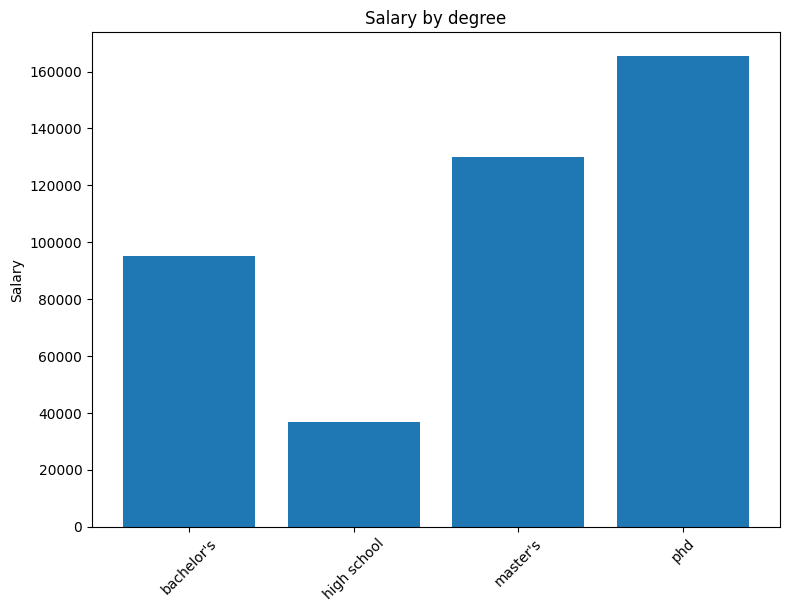

In [13]:
plt.figure(figsize=(8,6))
plt.bar(df_degree['Education Level'], df_degree['Salary'])
plt.ylabel('Salary')
plt.xticks(rotation=45)
plt.tight_layout()
plt.title('Salary by degree')
plt.show()

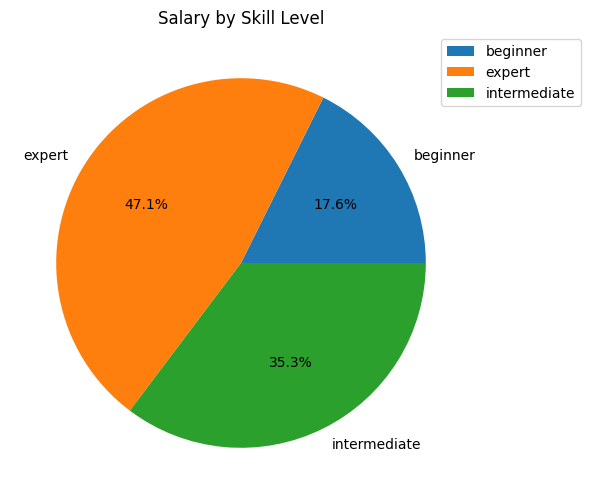

In [14]:
plt.figure(figsize=(8, 6))
plt.pie(df_skill['Salary'], labels=df_skill['skill_level'],autopct='%1.1f%%')
plt.title('Salary by Skill Level')
plt.legend(loc='upper right',bbox_to_anchor=(1.25, 1))
plt.show()

# Linear regression

In [15]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
from sklearn.preprocessing import LabelEncoder

In [16]:
df.head()

,Education Level,Years of Experience,Salary,skill_level
0,bachelor's,5.0,90000.0,beginner
1,master's,3.0,65000.0,beginner
2,phd,15.0,150000.0,intermediate
3,bachelor's,7.0,60000.0,intermediate
4,master's,20.0,200000.0,expert


In [17]:
le=LabelEncoder()
df['Education_encoded']=le.fit_transform(df['Education Level'])
df.head()

,Education Level,Years of Experience,Salary,skill_level,Education_encoded
0,bachelor's,5.0,90000.0,beginner,0
1,master's,3.0,65000.0,beginner,2
2,phd,15.0,150000.0,intermediate,3
3,bachelor's,7.0,60000.0,intermediate,0
4,master's,20.0,200000.0,expert,2


In [18]:
#assigning x and y and coverting to numpy arrays
x=df[['Years of Experience','Education_encoded']].values
y=df['Salary'].values

In [19]:
#splitting the data into training and testing data
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
print('x_train:',x_train)
print('y_train:',y_train)


x_train: [[10.  2.]
 [10.  2.]
 [12.  3.]
 ...
 [ 1.  0.]
 [ 1.  0.]
 [ 2.  0.]]
y_train: [105000. 155000. 175000. ...  55000.  55000. 110000.]


In [20]:
#viewing x_test and y_test
print('x_test:',x_test)
print('y_test:',y_test)

x_test: [[ 9.  2.]
 [ 4.  2.]
 [ 1.  2.]
 ...
 [ 6.  3.]
 [10.  0.]
 [ 3.  0.]]
y_test: [150000.  75969. 100000. ... 105000.  55000.  60000.]


In [21]:
#creating model and training it
model=LinearRegression()
model.fit(x_train, y_train)
y_pred=model.predict(x_test)

In [22]:
pd.DataFrame({'actual': y_test, 'predicted': y_pred}).head()

,actual,predicted
0,150000.0,125275.307134
1,75969.0,92764.496084
2,100000.0,73258.009453
3,60000.0,75947.054516
4,80000.0,88951.378937


In [23]:
#calculating intercept and coefficients (y=a1x1+a2x2+c)
print("Intercept:", model.intercept_)
print("a1,a2:", model.coef_)

Intercept: 56440.56788619103
a1,a2: [6502.1622101 5157.6396785]


# Error metrics

In [24]:
#calculating mae(mean absolute error)
mae=mean_absolute_error(y_test,y_pred)
print("MAE:",mae)
#calculating mse(mean squarred error)
mse=mean_squared_error(y_test,y_pred)
print("MSE:",mse)
#calculating r2_score
r2=r2_score(y_test,y_pred)
print("R2 Score:",r2)


MAE: 24347.157262085024
MSE: 949564962.5023894
R2 Score: 0.6669898182892774


# visualization

In [25]:
x_train

array([[10.,  2.],
       [10.,  2.],
       [12.,  3.],
       ...,
       [ 1.,  0.],
       [ 1.,  0.],
       [ 2.,  0.]], shape=(5358, 2))

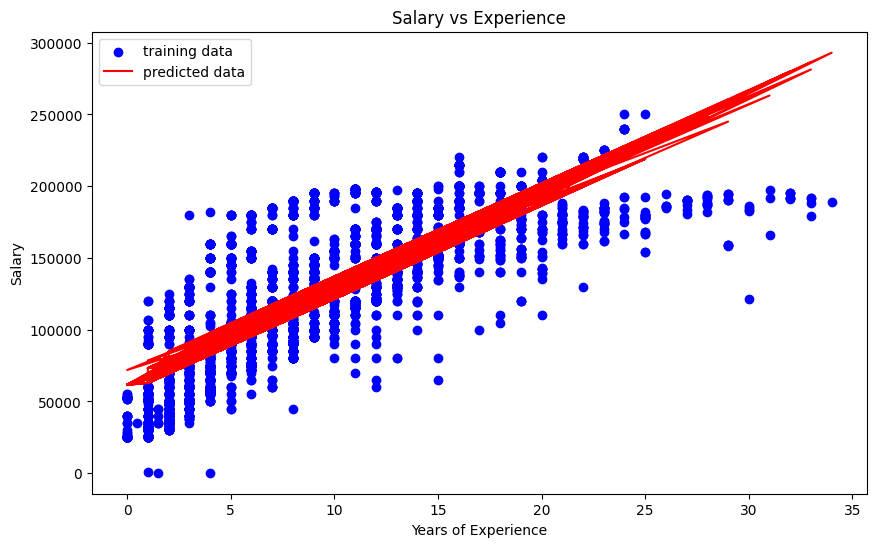

In [26]:
plt.figure(figsize=(10, 6))
plt.scatter(x_train[:,0],y_train,color='blue',label='training data')
plt.plot(x_test[:,0],y_pred,color='red',label='predicted data')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.title('Salary vs Experience')
plt.legend()
plt.show()

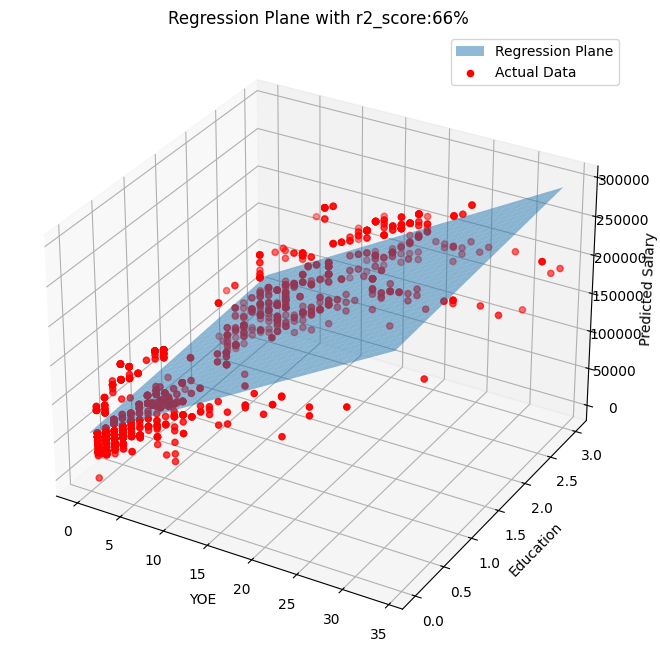

In [30]:
import matplotlib.pyplot as plt

# coefficients
intercept = 56440.56788619103
a1 = 6502.1622101
a2 = 5157.6396785

# Create grid
x1_range = np.linspace(x_test[:,0].min(), x_test[:,0].max(), 30)
x2_range = np.linspace(x_test[:,1].min(), x_test[:,1].max(), 30)

X1, X2 = np.meshgrid(x1_range, x2_range)

# Plane equation
Y = intercept + a1*X1 + a2*X2

# Plot
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')

# Regression plane
ax.plot_surface(X1, X2, Y, alpha=0.5,label='Regression Plane')

# Actual data points
ax.scatter(x_test[:,0], x_test[:,1], y_test,color='red',label='Actual Data')

ax.set_xlabel('YOE')
ax.set_ylabel('Education')
ax.set_zlabel('Predicted Salary')
plt.title('Regression Plane with r2_score:66%')
plt.legend()
plt.show()